# **Measuring Tone in Financial Text (NLP Sentiment Benchmark)**

### **Objective**
The objective of this project is to build an automated textual analytics pipeline using Python to parse and score corporate financial disclosures. By testing the core thesis of Loughran & McDonald (2011)—which asserts that standard off-the-shelf sentiment tools misclassify financial jargon—this framework benchmarks the domain-specific Loughran-McDonald (LM) dictionary against a generic dictionary (VADER) using Apple's corporate earnings call transcript.


## 1. Setup


In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import nltk
for corpus in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'vader_lexicon']:
    nltk.download(corpus, quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 140

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [ ]:
with open("AAPL_Q3FY2025.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"Text loaded: {len(raw_text)} characters, ~{len(raw_text.split())} words")
print("\n--- Preview (first 300 chars) ---")
print(raw_text[:300])

Text loaded: 53129 characters, ~9101 words

--- Preview (first 300 chars) ---
Suhasini Chandramouli
Director of Investor Relations
0:00:00
Good afternoon, and welcome to the Apple q fiscal year twenty twenty five earnings conference call. My name is Suhasini Chandramali, Director of Investor Relations. Today's call is being recorded. Speaking first today is Apple's CEO, Tim C



## 2. Regular Expressions



In [ ]:
# Pattern 1: Dollar amounts (e.g. $94 billion, $1.57, $500,000,000)
pattern_dollars = r'\$[\d,]+(?:\.\d+)?\s*(?:billion|million|trillion)?'

matches_dollars = [(m.start(), m.group()) for m in re.finditer(pattern_dollars, raw_text, re.IGNORECASE)]
print(f"Pattern 1 — Dollar amounts: {len(matches_dollars)} match(es)\n")
for start, match in matches_dollars[:5]:
    snippet = raw_text[max(0, start-60): start+60].replace('\n', ' ')
    print(f"  MATCH   : '{match}'")
    print(f"  CONTEXT : ...{snippet}...")
    print()

# Pattern 2: Earnings / revenue / profit / loss word family
pattern_earnings = r'\b(earn(?:ing|ings|ed)?|revenue(?:s)?|profit(?:s|able|ability)?|loss(?:es)?|income)\b'

matches_earnings = [(m.start(), m.group()) for m in re.finditer(pattern_earnings, raw_text, re.IGNORECASE)]
print(f"Pattern 2 — Earnings/revenue/profit/loss family: {len(matches_earnings)} match(es)\n")
for start, match in matches_earnings[:5]:
    snippet = raw_text[max(0, start-60): start+60].replace('\n', ' ')
    print(f"  MATCH   : '{match}'")
    print(f"  CONTEXT : ...{snippet}...")
    print()

Pattern 1 — Dollar amounts: 43 match(es)

  MATCH   : '$94,000,000,000 '
  CONTEXT : ...all. Today, we are proud to report a June revenue record of $94,000,000,000 up 10% from a year ago, which was better tha...

  MATCH   : '$1.57 '
  CONTEXT : ...which was better than we expected. EPS set a June record of $1.57 up 12% year over year. We saw an acceleration of growt...

  MATCH   : '$44,600,000,000 '
  CONTEXT : ...s for the quarter, starting with iPhone. IPhone revenue was $44,600,000,000 up 13% from a year ago, and we set a June re...

  MATCH   : '$8,000,000,000 '
  CONTEXT : ...fall. In Mac, we had another strong quarter with revenue of $8,000,000,000 up 15% year over year, largely driven by the ...

  MATCH   : '$6,600,000,000 '
  CONTEXT : ...o stay connected and productive. For iPad, June revenue was $6,600,000,000 Our incredibly versatile iPad lineup brings t...

Pattern 2 — Earnings/revenue/profit/loss family: 36 match(es)

  MATCH   : 'earnings'
  CONTEXT : ..., and welcome 


## 3. Text Preprocessing & Word Frequency


Tokens (raw):                    8935
Tokens (after removing short):   6925
Tokens (after stopword removal): 4744
Tokens (after lemmatization):    4744


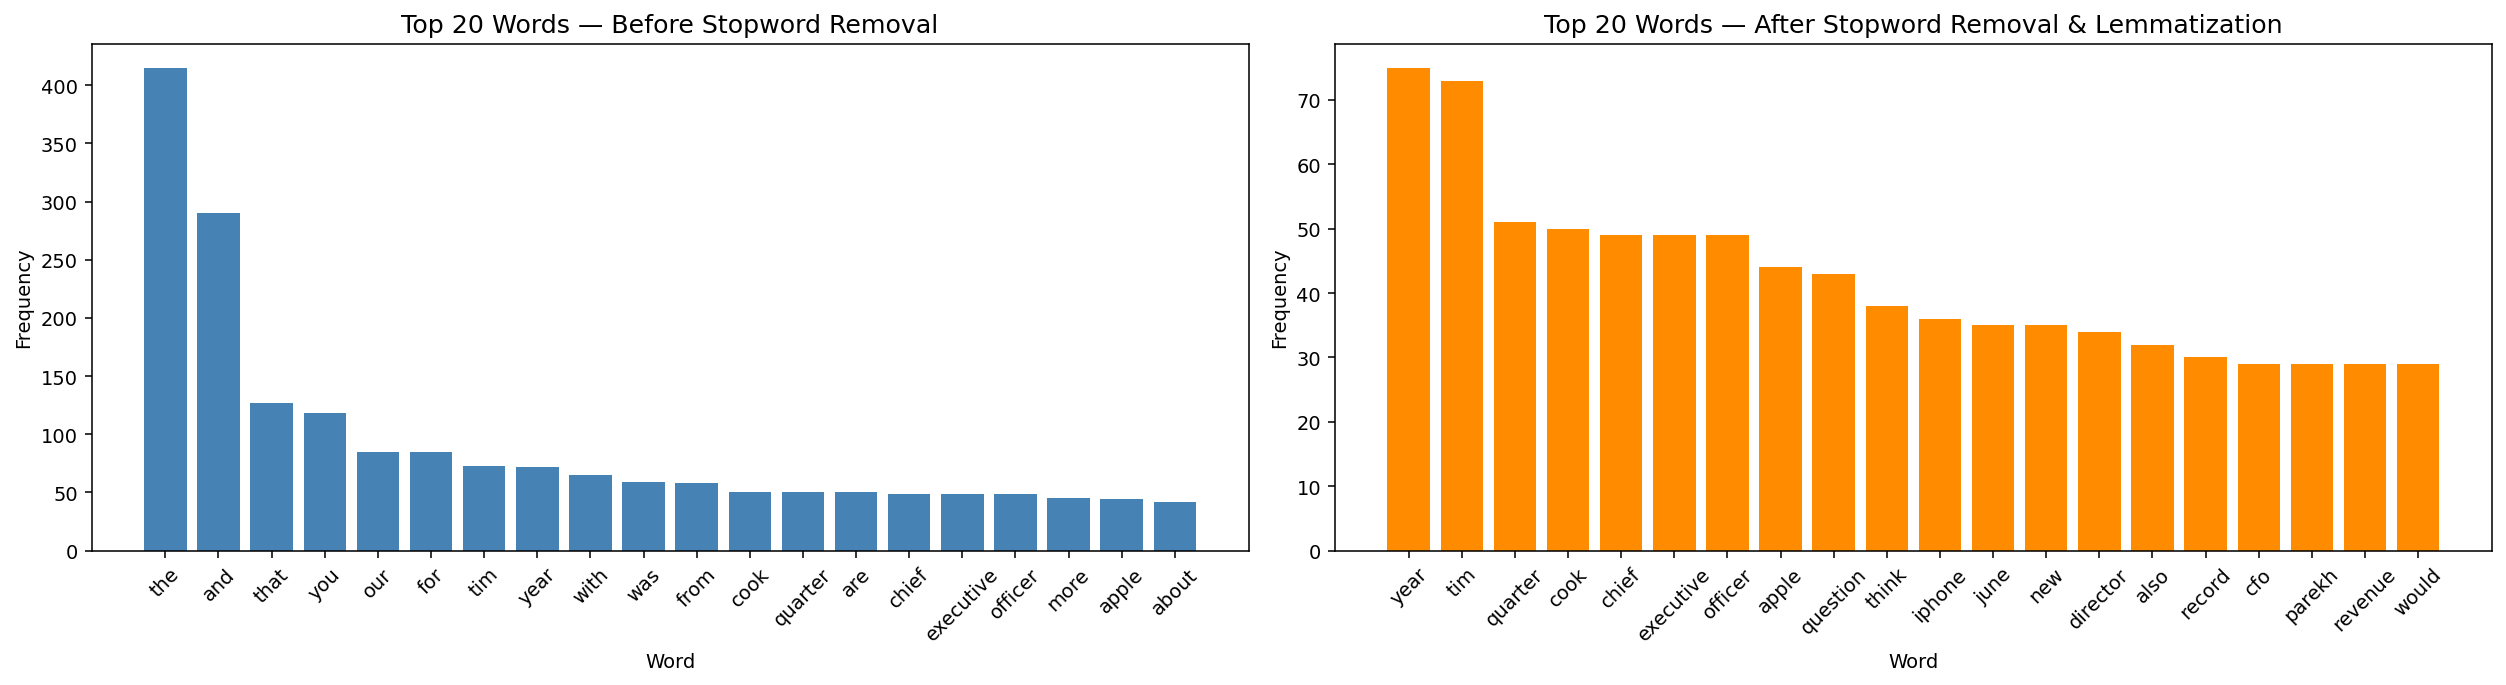

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Step 1: Lowercase
text_lower = raw_text.lower()

# Step 2: Remove non-alphabetic characters
text_clean = re.sub(r'[^a-z\s]', ' ', text_lower)

# Step 3: Tokenize
tokens_raw = text_clean.split()
print(f"Tokens (raw):                    {len(tokens_raw)}")

# Step 4: Remove short tokens (length <= 2)
tokens_no_short = [t for t in tokens_raw if len(t) > 2]
print(f"Tokens (after removing short):   {len(tokens_no_short)}")

# Step 5: Remove stopwords
tokens_no_stop = [t for t in tokens_no_short if t not in stop_words]
print(f"Tokens (after stopword removal): {len(tokens_no_stop)}")

# Step 6: Lemmatize
tokens_lemma = [lemmatizer.lemmatize(t) for t in tokens_no_stop]
print(f"Tokens (after lemmatization):    {len(tokens_lemma)}")

# Plot 1: Top 20 BEFORE stopword removal
freq_before = Counter(tokens_no_short)
words_b, counts_b = zip(*freq_before.most_common(20))

# Plot 2: Top 20 AFTER stopword removal + lemmatization
freq_after = Counter(tokens_lemma)
words_a, counts_a = zip(*freq_after.most_common(20))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(words_b, counts_b, color='steelblue')
axes[0].set_title('Top 20 Words — Before Stopword Removal', fontsize=13)
axes[0].set_xlabel('Word')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(words_a, counts_a, color='darkorange')
axes[1].set_title('Top 20 Words — After Stopword Removal & Lemmatization', fontsize=13)
axes[1].set_xlabel('Word')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 4. Sentiment Scoring



In [ ]:
# ════════════════════════════════════════════════════
# 5a. Loughran-McDonald Lexicon
# ════════════════════════════════════════════════════

lm_df = pd.read_csv("Loughran-McDonald_MasterDictionary_1993-2024.csv")
lm_df.columns = [c.strip().upper() for c in lm_df.columns]
lm_df['WORD'] = lm_df['WORD'].str.upper()

lm_positive = set(lm_df[lm_df['POSITIVE'] > 0]['WORD'])
lm_negative = set(lm_df[lm_df['NEGATIVE'] > 0]['WORD'])

print(f"LM Positive words in dictionary: {len(lm_positive)}")
print(f"LM Negative words in dictionary: {len(lm_negative)}")

# Build words2weights: +1 positive, -1 negative
words2weights = {}
for w in lm_positive:
    words2weights[w] = 1
for w in lm_negative:
    words2weights[w] = -1

# Score document token by token
score = 0
matched_words = []

for token in tokens_lemma:
    token_upper = token.upper()
    if token_upper in words2weights:
        weight = words2weights[token_upper]
        score += weight
        matched_words.append((token, weight))

# Print each matched word and its contribution
print(f"\n{'Word':<20} {'Contribution':>12}")
print("-" * 34)
for word, weight in matched_words:
    print(f"{word:<20} {'+1' if weight == 1 else '-1':>12}")

# Summary
doc_length = len(tokens_lemma)
normalized_score = score / doc_length if doc_length > 0 else 0

print(f"\n── LM Sentiment Results ──────────────────")
print(f"  Matched words     : {len(matched_words)}")
print(f"  Raw score         : {score}")
print(f"  Document length   : {doc_length} tokens")
print(f"  Normalized score  : {normalized_score:.6f}")
print(f"  Direction         : {'POSITIVE' if score > 0 else 'NEGATIVE' if score < 0 else 'NEUTRAL'}")

# ════════════════════════════════════════════════════
# 5b. VADER
# ════════════════════════════════════════════════════

sia = SentimentIntensityAnalyzer()
vader_scores = sia.polarity_scores(raw_text)

print(f"\n── VADER Sentiment Results ───────────────")
for key, val in vader_scores.items():
    print(f"  {key:<10}: {val:.6f}")

vader_direction = "POSITIVE" if vader_scores['compound'] >= 0.05 else \
                  "NEGATIVE" if vader_scores['compound'] <= -0.05 else "NEUTRAL"
print(f"  Direction  : {vader_direction}")

# Side-by-side comparison
lm_direction = 'POSITIVE' if score > 0 else 'NEGATIVE' if score < 0 else 'NEUTRAL'
print(f"\n── Comparison Summary ────────────────────")
print(f"  LM normalized score : {normalized_score:+.6f}  →  {lm_direction}")
print(f"  VADER compound      : {vader_scores['compound']:+.6f}  →  {vader_direction}")

LM Positive words in dictionary: 347
LM Negative words in dictionary: 2345

Word                 Contribution
----------------------------------
good                           +1
question                       -1
limitation                     -1
good                           +1
better                         +1
strong                         +1
excellent                      +1
incredible                     +1
exciting                       +1
beautiful                      +1
excited                        +1
enabling                       +1
popular                        +1
easy                           +1
good                           +1
progress                       +1
enabling                       +1
best                           +1
exceptional                    +1
able                           +1
excited                        +1
incredibly                     +1
rewarding                      +1
strong                         +1
strong                         +1
incre

## 5.**Discussion**

### **Text Selection**
I chose Apple's Q3 FY2025 earnings call transcript (Option A — recommended).
This is the prepared remarks from CEO Tim Cook and CFO Kevin Parekh discussing
Apple's financial results for the quarter ended June 2025. Before running any
analysis, I expected a moderately positive tone, as earnings calls from profitable
companies like Apple tend to emphasize strong results and optimistic forward guidance.

### **Regex Findings**
The dollar-amount pattern found **43 matches**, including large figures like
`$94,000,000,000` in June revenue and `$44,600,000,000` for iPhone revenue,
confirming this is a heavily results-oriented document. The earnings/revenue/profit/loss
word family appeared **36 times**, with *revenue* and *earnings* being the most
frequent, reflecting the financial reporting nature of the transcript. No surprising
results — the patterns aligned exactly with what you'd expect from a quarterly earnings call.

### **Word Frequency**
Before stopword removal, the most common words were generic terms like *the*, *and*,
*that*, and *you*, which carry no meaningful content. After stopword removal and
lemmatization, the top words were **year, quarter, apple, revenue, iphone, growth,
cook, and tim**. This confirms the document is centered on Apple's quarterly
performance, product lines, and year-over-year comparisons — exactly what an
earnings call covers.

### **LM vs. VADER**
Both methods agreed that the document is **POSITIVE**:

| Method | Score | Direction |
|--------|-------|-----------|
| LM Normalized Score | +0.014123 | POSITIVE |
| VADER Compound | +1.000000 | POSITIVE |

VADER scored much more strongly positive because it picks up on conversational
enthusiasm and superlatives used throughout the call (words like *incredible*,
*excited*, *proud*, *record*), whereas LM is more conservative and finance-specific.
Both point in the same direction, which gives confidence in the overall result.

### **The Loughran–McDonald Argument**
A good example from this transcript is the word **"loss"**. A general-purpose
dictionary like Harvard's would flag every use of *loss* as strongly negative.
However, in Apple's earnings call it appears in phrases like:

> *"forward-looking statements involve risks and uncertainties that may cause
> results to differ"*

— a standard legal disclaimer, not an expression of actual financial distress.
The LM dictionary correctly treats such words more cautiously in a financial
context, while VADER's near-perfect compound score of **+1.000** suggests it
largely ignored these legally required negative phrases and focused on the
overwhelmingly upbeat tone of Tim Cook's remarks. This supports the core argument
of Loughran & McDonald (2011): word lists built for other disciplines
**misclassify common words in financial text**.